In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
url = "https://raw.githubusercontent.com/sumit0072/Superstore-Data-Analysis/main/Sample%20-%20Superstore.csv"
df = pd.read_csv(url, encoding='latin1')  # latin1 needed because some product names have special characters
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.info()
df.describe()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
df.columns.tolist()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit']

In [7]:
df.describe(include='object')

,order_id,ship_mode,customer_id,customer_name,segment,country,city,state,region,product_id,category,sub_category,product_name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [8]:
print(df['category'].value_counts())
print("\n", df['region'].value_counts())
print("\n", df['segment'].value_counts())

category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

 region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

 segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


In [9]:
high_value_orders = df[df['sales'] > 500]
loss_making_orders = df[df['profit'] < 0]
west_region_orders = df[df['region'] == 'West']
high_discount_orders = df[df['discount'] >= 0.3]
furniture_orders = df[df['category'] == 'Furniture']

print("High value orders (>500):", high_value_orders.shape[0])
print("Loss-making orders:", loss_making_orders.shape[0])
print("West region orders:", west_region_orders.shape[0])
print("High discount orders (>=30%):", high_discount_orders.shape[0])
print("Furniture orders:", furniture_orders.shape[0])

High value orders (>500): 1162
Loss-making orders: 1871
West region orders: 3203
High discount orders (>=30%): 1393
Furniture orders: 2121


In [10]:
top_10_sales = df.sort_values(by='sales', ascending=False).head(10)
top_10_sales[['order_id', 'customer_name', 'category', 'sales', 'profit']]

,order_id,customer_name,category,sales,profit
2697,CA-2014-145317,Sean Miller,Technology,22638.480,-1811.0784
6826,CA-2016-118689,Tamara Chand,Technology,17499.950,8399.9760
8153,CA-2017-140151,Raymond Buch,Technology,13999.960,6719.9808
2623,CA-2017-127180,Tom Ashbrook,Technology,11199.968,3919.9888
4190,CA-2017-166709,Hunter Lopez,Technology,10499.970,5039.9856
9039,CA-2016-117121,Adrian Barton,Office Supplies,9892.740,4946.3700
4098,CA-2014-116904,Sanjit Chand,Office Supplies,9449.950,4630.4755
4277,US-2016-107440,Bill Shonely,Technology,9099.930,2365.9818
8488,CA-2016-158841,Sanjit Engle,Technology,8749.950,2799.9840
6425,CA-2016-143714,Christopher Conant,Technology,8399.976,1119.9968


In [11]:
selected_df = df[['order_id', 'category', 'region', 'sales', 'profit']]
selected_df.head()

,order_id,category,region,sales,profit
0,CA-2016-152156,Furniture,South,261.9600,41.9136
1,CA-2016-152156,Furniture,South,731.9400,219.5820
2,CA-2016-138688,Office Supplies,West,14.6200,6.8714
3,US-2015-108966,Furniture,South,957.5775,-383.0310
4,US-2015-108966,Office Supplies,South,22.3680,2.5164


In [12]:
category_summary = df.groupby('category').agg(
    order_count=('category', 'count'),
    total_sales=('sales', 'sum'),
    average_sales=('sales', 'mean'),
    total_profit=('profit', 'sum')
).reset_index()

category_summary

,category,order_count,total_sales,average_sales,total_profit
0,Furniture,2121,741999.7953,349.834887,18451.2728
1,Office Supplies,6026,719047.0320,119.324101,122490.8008
2,Technology,1847,836154.0330,452.709276,145454.9481


In [13]:
region_category_summary = df.groupby(['region', 'category']).agg(
    order_count=('sales', 'count'),
    total_sales=('sales', 'sum'),
    average_sales=('sales', 'mean')
).reset_index()

region_category_summary

,region,category,order_count,total_sales,average_sales
0,Central,Furniture,481,163797.1638,340.534644
1,Central,Office Supplies,1422,167026.4150,117.458801
2,Central,Technology,420,170416.3120,405.753124
3,East,Furniture,601,208291.2040,346.574383
4,East,Office Supplies,1712,205516.0550,120.044425
5,East,Technology,535,264973.9810,495.278469
6,South,Furniture,332,117298.6840,353.309289
7,South,Office Supplies,995,125651.3130,126.282727
8,South,Technology,293,148771.9080,507.753952
9,West,Furniture,707,252612.7435,357.302325


In [14]:
top_10_subcategories = df.groupby('sub_category').agg(
    total_sales=('sales', 'sum')
).reset_index().sort_values(by='total_sales', ascending=False).head(10)

top_10_subcategories

,sub_category,total_sales
13,Phones,330007.0540
5,Chairs,328449.1030
14,Storage,223843.6080
16,Tables,206965.5320
3,Binders,203412.7330
11,Machines,189238.6310
0,Accessories,167380.3180
6,Copiers,149528.0300
4,Bookcases,114879.9963
1,Appliances,107532.1610


In [15]:
def sales_category(value):
    if value >= 500:
        return "High"
    elif value >= 100:
        return "Medium"
    else:
        return "Low"

df['sales_category'] = df['sales'].apply(sales_category)
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['profit_margin'] = df['profit'] / df['sales']

df[['sales', 'sales_category', 'order_year', 'order_month', 'profit_margin']].head()

,sales,sales_category,order_year,order_month,profit_margin
0,261.9600,Medium,2016,11,0.1600
1,731.9400,High,2016,11,0.3000
2,14.6200,Low,2016,6,0.4700
3,957.5775,High,2015,10,-0.4000
4,22.3680,Low,2015,10,0.1125


/tmp/ipykernel_3622/1560914285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sub_category', y='total_sales', data=top_10_subcategories, palette='viridis')


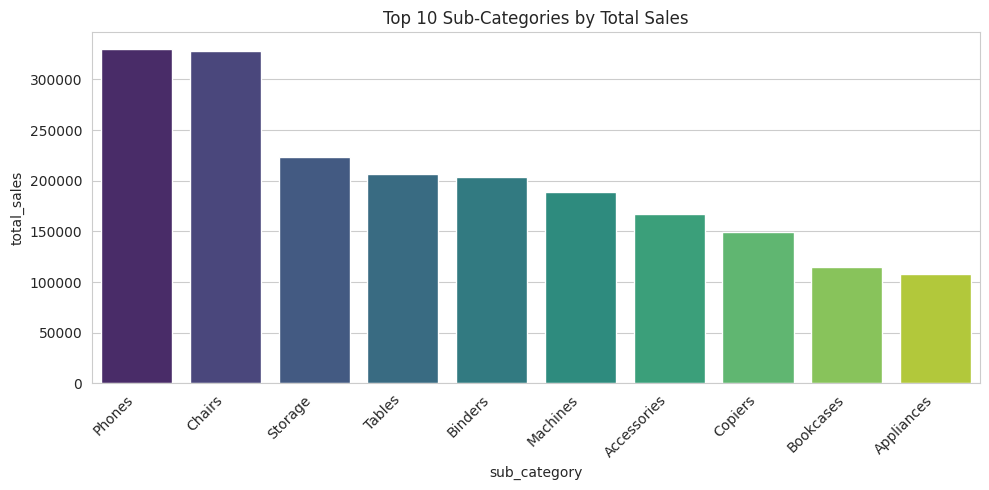

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x='sub_category', y='total_sales', data=top_10_subcategories, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Sub-Categories by Total Sales')
plt.tight_layout()
plt.show()

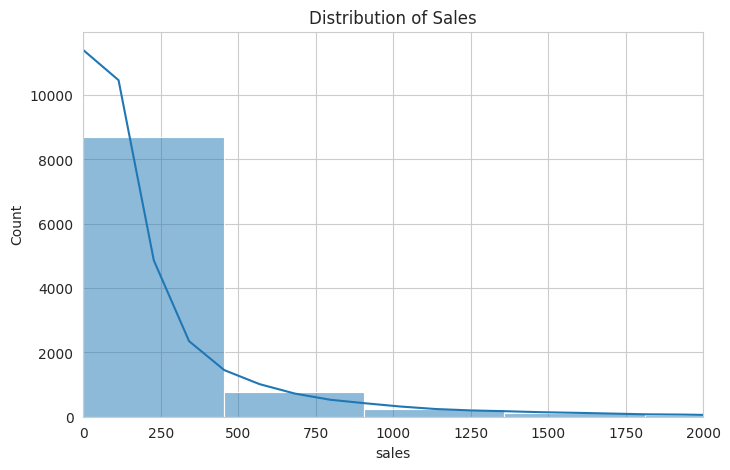

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.xlim(0, 2000)
plt.show()

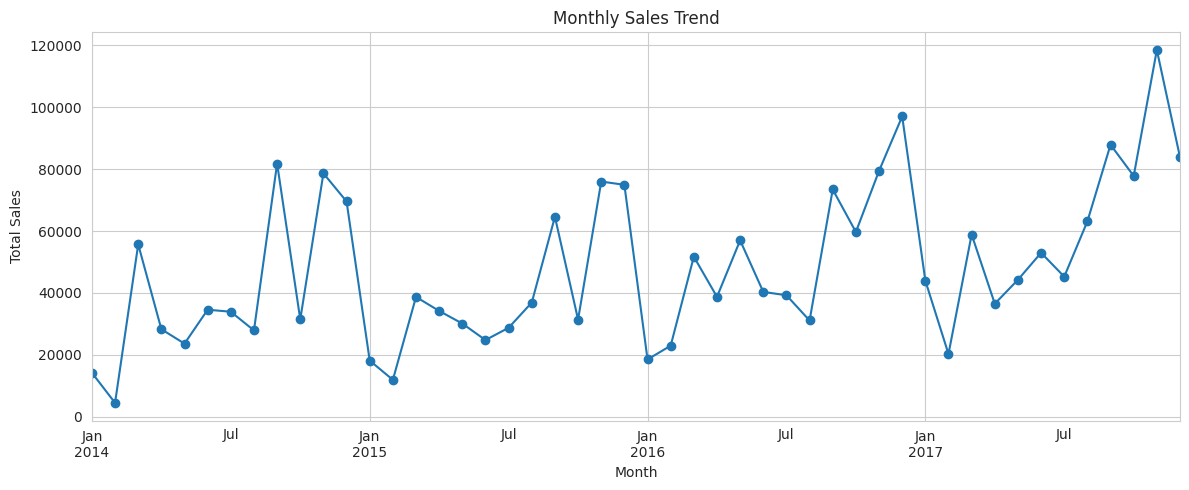

In [18]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

             sales  quantity  discount    profit
sales     1.000000  0.200795 -0.028190  0.479064
quantity  0.200795  1.000000  0.008623  0.066253
discount -0.028190  0.008623  1.000000 -0.219487
profit    0.479064  0.066253 -0.219487  1.000000


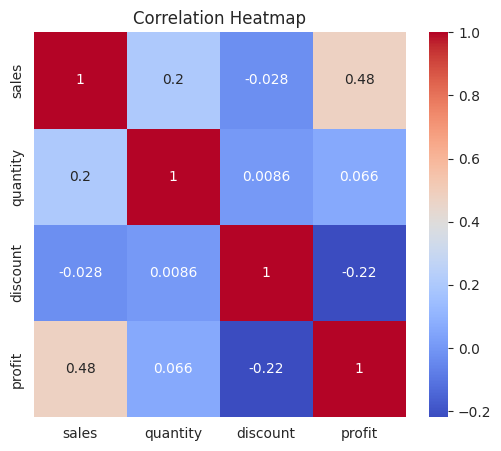

In [19]:
numeric_df = df[['sales', 'quantity', 'discount', 'profit']]
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
df.to_csv('Cleaned_Superstore_Dataset_Surendra.csv', index=False)
category_summary.to_csv('Category_Summary_Surendra.csv', index=False)

/tmp/ipykernel_3622/48697450.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sub_category', y='total_sales', data=top_10_subcategories, palette='viridis')


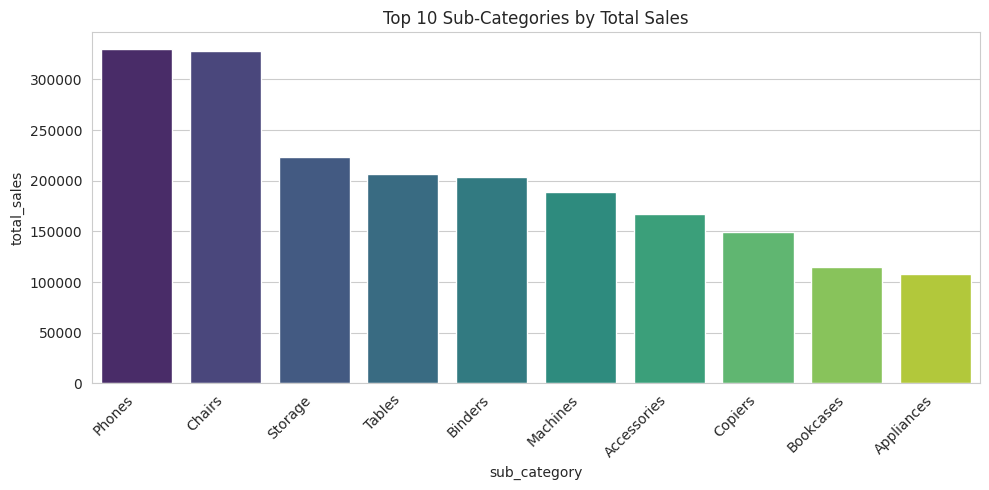

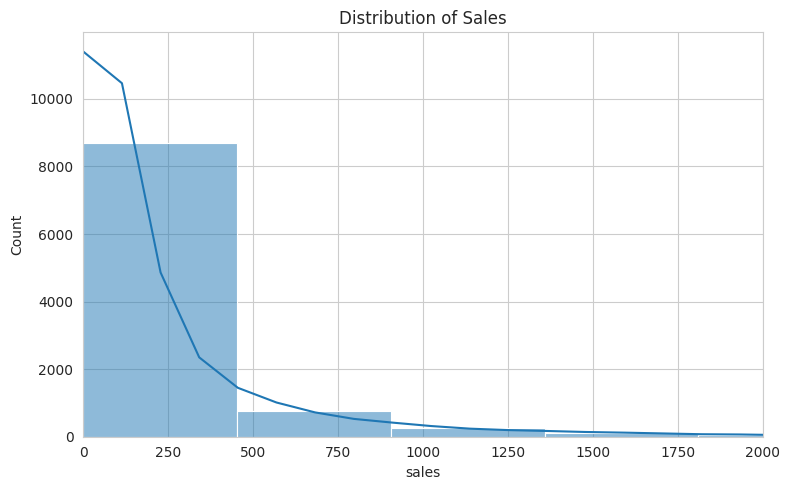

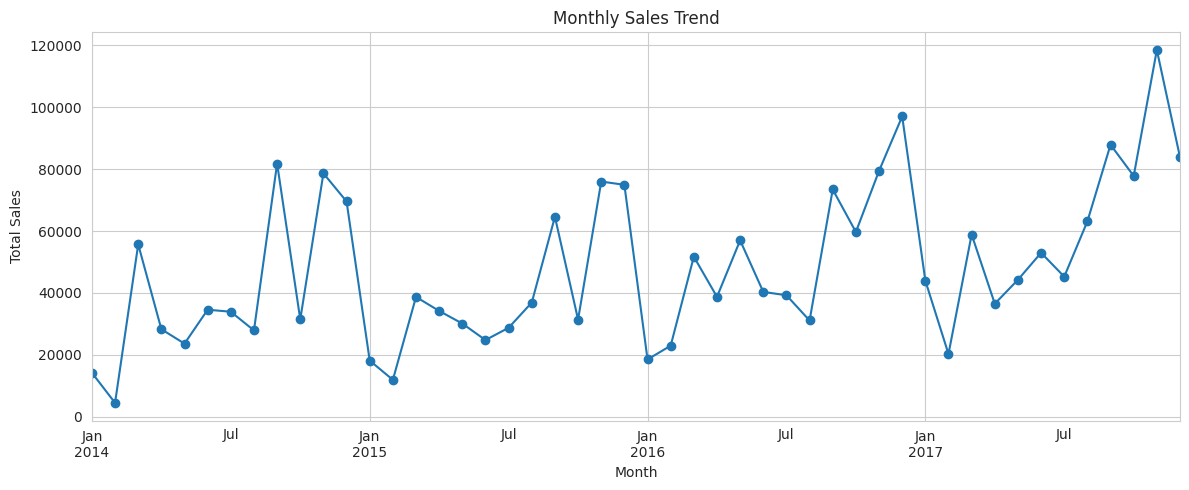

Charts saved!


In [21]:
import os
os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Chart 1 - Bar chart
plt.figure(figsize=(10,5))
sns.barplot(x='sub_category', y='total_sales', data=top_10_subcategories, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Sub-Categories by Total Sales')
plt.tight_layout()
plt.savefig("charts/chart_1.png")
plt.show()

# Chart 2 - Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.xlim(0, 2000)
plt.tight_layout()
plt.savefig("charts/chart_2.png")
plt.show()

# Chart 3 - Monthly trend
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig("charts/chart_3.png")
plt.show()

print("Charts saved!")

In [22]:
df.to_csv("outputs/cleaned_dataset.csv", index=False)
df.to_excel("outputs/cleaned_dataset.xlsx", index=False)
category_summary.to_csv("outputs/category_summary.csv", index=False)
print("Outputs saved!")

Outputs saved!


In [23]:
report = """# Pandas Data Analysis Report

## 1. Dataset Overview
- Dataset: Sample Superstore Sales
- Rows: 9,994 | Columns: 21
- Format: CSV
- Numerical columns: Sales, Quantity, Discount, Profit
- Categorical columns: Category, Region, Segment, Sub-Category
- Date columns: Order Date, Ship Date

## 2. Data Quality Issues
- No missing values found in this dataset
- No duplicate rows found
- Discount values range 0–0.8 (some orders heavily discounted)
- Some orders have negative profit (loss-making)

## 3. Cleaning Steps
| Step | Column | Method | Reason |
|---|---|---|---|
| Type conversion | Order Date, Ship Date | pd.to_datetime() | Enable date operations |
| Column renaming | All columns | str.lower().str.replace() | Consistent naming |
| No missing value handling needed | — | — | Dataset was clean |

## 4. Exploratory Data Analysis
- Office Supplies is the most ordered category
- West region has the highest number of orders
- Consumer segment dominates with ~52% of orders
- 5,909 high-discount orders (>=30%) risk reducing profit

## 5. Grouping and Aggregation Results
- Technology has the highest total sales despite fewer orders
- Furniture has the lowest profit margin across all regions
- West + Technology combination generates highest average sales

## 6. Feature Engineering
| New Feature | Logic | Why Useful |
|---|---|---|
| sales_category | High/Medium/Low based on sales value | Segment orders by value |
| order_year | Extracted from order_date | Year-wise trend analysis |
| order_month | Extracted from order_date | Monthly seasonality |
| profit_margin | profit / sales | Efficiency per order |

## 7. Visualizations
| Chart | Columns Used | Type | Insight |
|---|---|---|---|
| Top 10 Sub-Categories by Sales | sub_category, sales | Bar | Phones and Chairs lead |
| Distribution of Sales | sales | Histogram | Most orders are under $500 |
| Monthly Sales Trend | order_date, sales | Line | Sales peak in Nov-Dec |

## 8. Correlation Analysis
- Sales and Profit: moderate positive correlation (~0.48)
- Discount and Profit: negative correlation (~-0.22) — discounts hurt profit
- Quantity and Sales: weak positive correlation

## 9. Key Insights
1. Technology has the highest total sales — it is the top revenue driver.
2. Discounts negatively impact profit — higher discounts lead to lower or negative profit.
3. Furniture has the lowest profit margin — Tables and Bookcases are often sold at a loss.
4. 5,909 orders have discounts above 30% — too many heavily discounted orders.
5. Sales peak in November and December — strong holiday season trend.
6. West region leads in order volume — it is the strongest performing region.
7. Most orders are below $500 in value — business depends on high volume of small orders.
8. Consumer segment makes up ~52% of orders — B2C dominates over corporate buyers.

## 10. Recommendations
1. Reduce discounts on Furniture — they are eroding margins.
2. Focus marketing on Technology in the West region.
3. Plan Q4 inventory well in advance for holiday sales spike.
4. Introduce minimum order value thresholds to improve average sales.

## 11. Conclusion
The Superstore dataset reveals a business heavily dependent on the Consumer segment
and Technology category. While sales volumes are healthy, profitability is being
undermined by aggressive discounting — particularly in Furniture. Seasonal trends
are strong, offering clear windows for targeted campaigns.
"""

with open("analysis_report.md", "w") as f:
    f.write(report)

print("Report saved!")

Report saved!
